# Introduction

In this vignette, we will generate pseudobulk data for each cell type in the small intestine and the large intestine. This will generate the input required for part 2 of the vegnette where we will determine the differences in gene expression between the small intestine and the large intestine.

# Load libraries

In [2]:
# Import required libraries
import scanpy as sc
import pandas as pd
import numpy as np
import gc
import os

In [22]:
organoid = sc.read_h5ad("/labs/mpsnyder/abdalla/Intestine_scRNAseqAnalysis/HCA_GutWorkingGroup/h5ad_Files/organoid_query_predictions.h5ad")

In [23]:
list(organoid.obs['hgca_pred_celltype_sysvi_knn'].unique())

['Colonocyte Progenitors',
 'Enterocyte Progenitors',
 'Intestinal Stem Cells (ISC)',
 'Transiently Amplifying Cells (TA)',
 'Lower Crypt Colonocytes',
 'Lower Villus Enterocytes',
 'Mid Villus Enterocytes',
 'Crypt Top Colonocytes',
 'Mid Crypt Colonocytes',
 'Villus Tip Enterocytes',
 'BEST4 Colonocytes',
 'EEC Progenitors',
 'Goblet Cells',
 'BEST4 Enterocytes',
 'Tuft Progenitors',
 'EEC Enterochromaffin (EC)',
 'Secretory Progenitors',
 'Tuft Cells',
 'EEC N',
 'Mature Goblet Cells',
 'Foveolar Cells',
 'EEC L',
 'Paneth Cells',
 'EEC S',
 'Enteroendocrine Cells (EEC)',
 'Brunners Gland Cells',
 'Microfold Cells (M Cells)',
 'Epithelial']

In [24]:
organoid

AnnData object with n_obs × n_vars = 265728 × 4000
    obs: 'sample_id', 'publication', 'sample_name', 'n_genes', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'pct_counts_ribo', 'batch', 'derive', 'time', 'protocol', 'molecular', 'gel', 'leiden', 'leiden_10.0', 'level_1', 'level_2', 'level_3', 'level_1_original', 'level_2_original', 'level_3_original', 'tissue_ontology_term_id', 'assay_ontology_term_id', 'disease_ontology_term_id', 'cell_type_ontology_term_id', 'self_reported_ethnicity_ontology_term_id', 'development_stage_ontology_term_id', 'sex_ontology_term_id', 'donor_id', 'suspension_type', 'is_primary_data', 'tissue_type', 'cell_type', 'assay', 'disease', 'sex', 'tissue', 'self_reported_ethnicity', 'development_stage', 'observation_joinid', 'hgca_celltype_v1', 'dataset_id', '_scvi_batch', '_scvi_labels', 'hgca_pred_celltype_scvi_knn', 'hgca_pred_conf_scvi_knn', 'hgca_pred_entropy_scvi_knn', 'hgca_pred_celltype_scvi_knn_thresh', 'hg

In [25]:
# Check how many unique samples are there for each cell type
print("\n" + "="*80)
print("Number of unique samples per cell type:")
print("="*80)

sample_counts_per_celltype = organoid.obs.groupby('hgca_pred_celltype_sysvi_knn')['sample_id'].nunique().sort_values(ascending=False)
print(sample_counts_per_celltype)

# Also show the total number of cells per cell type
print("\n" + "="*80)
print("Number of cells per cell type:")
print("="*80)
cell_counts_per_celltype = organoid.obs['hgca_pred_celltype_sysvi_knn'].value_counts().sort_values(ascending=False)
print(cell_counts_per_celltype)


Number of unique samples per cell type:
hgca_pred_celltype_sysvi_knn
Transiently Amplifying Cells (TA)    96
Lower Crypt Colonocytes              93
Crypt Top Colonocytes                92
BEST4 Colonocytes                    91
Intestinal Stem Cells (ISC)          90
Enterocyte Progenitors               87
Colonocyte Progenitors               86
Lower Villus Enterocytes             82
Mid Villus Enterocytes               80
Villus Tip Enterocytes               78
Mid Crypt Colonocytes                74
Tuft Progenitors                     66
Tuft Cells                           61
BEST4 Enterocytes                    60
Goblet Cells                         55
EEC Enterochromaffin (EC)            55
EEC Progenitors                      52
Secretory Progenitors                43
EEC L                                39
Mature Goblet Cells                  37
EEC N                                34
Brunners Gland Cells                 33
Epithelial                           33
Enteroendo

/local/scratch/ahmedabd/slrmtmp.50834166/ipykernel_44171/3459401964.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  sample_counts_per_celltype = organoid.obs.groupby('hgca_pred_celltype_sysvi_knn')['sample_id'].nunique().sort_values(ascending=False)


In [26]:
list(organoid.obs['sample_id'].unique())

['Bein_FPhar_2021_all',
 'Beumer_Cell_2020_Col',
 'Beumer_Cell_2020_Duo',
 'Beumer_Cell_2020_Ile',
 'Beumer_CellRep_2022_all',
 'Fujii_CellStemCell_2018_hSMO_IF',
 'Fujii_CellStemCell_2018_hSMO_SB',
 'He_CellStemCell_2022_hSIO_IL22neg',
 'He_CellStemCell_2022_hSIO_IL22pos',
 'Sung_NO_2020_GSM4654340_TNF_free',
 'Sung_NO_2020_GSM4654341_TNF_treat',
 'Yan_Gut_2020_H011_NO',
 'Yan_Gut_2020_H011_NOd',
 'Yan_Gut_2020_H019_NO',
 'Yan_Gut_2020_H019_NOd',
 'Thispaper_Thispaper_2023_UK_Duo89',
 'Thispaper_Thispaper_2023_UK_R5_Duo81_hum_enteroids',
 'Thispaper_Thispaper_2023_UK_R6_Duo87_hum_enteroids',
 'Palikuqi_Nat_2020_GSM4487132_Sample1D',
 'Elmentaite_DevCell_2020_p17_p172038',
 'Elmentaite_DevCell_2020_p17_p172039',
 'Elmentaite_DevCell_2020_p1_TIp12038',
 'Elmentaite_DevCell_2020_p1_TIp12039',
 'Elmentaite_DevCell_2020_WNT3Aneg_2206_p2_RSPO',
 'Elmentaite_DevCell_2020_WNT3Apos_2206_p2_WNT3A',
 'Holloway_CellStemCell_2021_hITD_EGFNRG1_day105_S13',
 'Holloway_CellStemCell_2021_hITD_EGFNRG1_

In [29]:
# Get all unique cell types
cell_types = organoid.obs['hgca_pred_celltype_sysvi_knn'].unique()

# Create output directory
output_dir = "/labs/mpsnyder/abdalla/Intestine_scRNAseqAnalysis/HCA_GutWorkingGroup/pseudobulk_outputs_organoids"

for cell_type in cell_types:
    print(f"\nProcessing cell type: {cell_type}")
    
    # Subset for current cell type
    cell_subset = organoid[organoid.obs['hgca_pred_celltype_sysvi_knn'] == cell_type].copy()
    
    # Skip if too few samples
    if len(cell_subset.obs['sample_id'].unique()) < 3:  # Minimum 3 samples for DE analysis
        print(f"Skipping {cell_type} - insufficient samples ({len(cell_subset.obs['sample_id'].unique())})")
        continue
        
    # Pseudobulk aggregation
    aggregated_samples = []

    # Get unique sample_ids
    unique_samples = cell_subset.obs['sample_id'].unique()
    
    for sample_id in unique_samples:
        # Subset for this sample_id
        subset = cell_subset[cell_subset.obs['sample_id'] == sample_id]
        
        # Skip if no cells for this sample
        if subset.n_obs == 0:
            continue
            
        # Aggregate counts
        aggregated_counts = np.asarray(subset.X.sum(axis=0)).flatten()
        
        # Create AnnData object for this pseudobulk sample
        rep_adata = sc.AnnData(
            X=aggregated_counts.reshape(1, -1),
            var=subset.var[[]],
            obs=subset.obs.iloc[[0]].copy()
        )
        
        # Use sample_id as the sample name
        rep_adata.obs_names = [str(sample_id)]
        aggregated_samples.append(rep_adata)
    
    # Combine all samples
    if not aggregated_samples:  # Skip if no samples after filtering
        print(f"No valid samples for {cell_type} after aggregation")
        continue
        
    pb = sc.concat(aggregated_samples)
    
    # Save outputs
    counts = pd.DataFrame(pb.X, index=pb.obs_names, columns=pb.var_names)
    
    # Save with cell type in filename
    safe_cell_type = cell_type.replace("/", "_").replace(" ", "_")  # Handle special characters
    counts_file = f"{output_dir}/{safe_cell_type}_pseudobulk_counts.csv"
    metadata_file = f"{output_dir}/{safe_cell_type}_metadata.csv"
    
    counts.T.to_csv(counts_file)  # Transpose for DESeq2 (genes as rows, samples as columns)
    pb.obs.to_csv(metadata_file)
    
    print(f"Saved files for {cell_type}:")
    print(f"  - Counts: {counts_file}")
    print(f"  - Metadata: {metadata_file}")
    print(f"  - Samples: {pb.n_obs}, Genes: {pb.n_vars}, Cells aggregated: {subset.n_obs}")

print("\nCompleted processing all cell types!")



Processing cell type: Colonocyte Progenitors
Saved files for Colonocyte Progenitors:
  - Counts: /labs/mpsnyder/abdalla/Intestine_scRNAseqAnalysis/HCA_GutWorkingGroup/pseudobulk_outputs_organoids/Colonocyte_Progenitors_pseudobulk_counts.csv
  - Metadata: /labs/mpsnyder/abdalla/Intestine_scRNAseqAnalysis/HCA_GutWorkingGroup/pseudobulk_outputs_organoids/Colonocyte_Progenitors_metadata.csv
  - Samples: 86, Genes: 4000, Cells aggregated: 343

Processing cell type: Enterocyte Progenitors
Saved files for Enterocyte Progenitors:
  - Counts: /labs/mpsnyder/abdalla/Intestine_scRNAseqAnalysis/HCA_GutWorkingGroup/pseudobulk_outputs_organoids/Enterocyte_Progenitors_pseudobulk_counts.csv
  - Metadata: /labs/mpsnyder/abdalla/Intestine_scRNAseqAnalysis/HCA_GutWorkingGroup/pseudobulk_outputs_organoids/Enterocyte_Progenitors_metadata.csv
  - Samples: 87, Genes: 4000, Cells aggregated: 1227

Processing cell type: Intestinal Stem Cells (ISC)
Saved files for Intestinal Stem Cells (ISC):
  - Counts: /labs

## Load the human .h5ad file using scanpy

In [3]:
# Load the .h5ad file using scanpy
#adata_all_old = sc.read_h5ad("/labs/mpsnyder/abdalla/Intestine_scRNAseqAnalysis/HCA_GutWorkingGroup/h5ad_Files/gca_concatenated_anndata_March28_2025.h5ad")
#adata_all = sc.read_h5ad("/labs/mpsnyder/abdalla/Intestine_scRNAseqAnalysis/HCA_GutWorkingGroup/h5ad_Files/20250717_CxG_upload_checkpoint.h5ad")
myeloid = sc.read_h5ad("/labs/mpsnyder/abdalla/Intestine_scRNAseqAnalysis/HCA_GutWorkingGroup/h5ad_Files/myeloid.h5ad")
epithelial = sc.read_h5ad("/labs/mpsnyder/abdalla/Intestine_scRNAseqAnalysis/HCA_GutWorkingGroup/h5ad_Files/epithelial.h5ad")
lymphoid = sc.read_h5ad("/labs/mpsnyder/abdalla/Intestine_scRNAseqAnalysis/HCA_GutWorkingGroup/h5ad_Files/lymphoid.h5ad")
stroma = sc.read_h5ad("/labs/mpsnyder/abdalla/Intestine_scRNAseqAnalysis/HCA_GutWorkingGroup/h5ad_Files/stroma.h5ad")
adata_all = sc.concat([myeloid, epithelial, lymphoid, stroma], join='outer',  label='cell_type', keys=['myeloid', 'epithelial', 'lymphoid', 'stroma'])

To enable us to compare absorptive epithelial cells in the small intestine and the large intestine we need to rename "Enterocytes" and "Colonocytes" as "Absorptive Epithelial"

In [3]:
adata_all.obs['hgca_celltype_v1'] = adata_all.obs['hgca_celltype_v1'].str.replace('/', '_')
adata_all.obs['hgca_celltype_v1'] = adata_all.obs['hgca_celltype_v1'].str.replace('Colonocyte', 'Absorptive Epithelial')
adata_all.obs['hgca_celltype_v1'] = adata_all.obs['hgca_celltype_v1'].str.replace('Enterocyte', 'Absorptive Epithelial')
adata_all.obs['hgca_celltype_v1'] = adata_all.obs['hgca_celltype_v1'].str.replace('Lower Villus', 'Lower')
adata_all.obs['hgca_celltype_v1'] = adata_all.obs['hgca_celltype_v1'].str.replace('Mid Villus', 'Mid')
adata_all.obs['hgca_celltype_v1'] = adata_all.obs['hgca_celltype_v1'].str.replace('Villus Tip', 'Top')
adata_all.obs['hgca_celltype_v1'] = adata_all.obs['hgca_celltype_v1'].str.replace('Lower Crypt', 'Lower')
adata_all.obs['hgca_celltype_v1'] = adata_all.obs['hgca_celltype_v1'].str.replace('Mid Crypt', 'Mid')
adata_all.obs['hgca_celltype_v1'] = adata_all.obs['hgca_celltype_v1'].str.replace('Crypt Top', 'Top')
unique_annotations = adata_all.obs[['hgca_celltype_v1', 'cell_type']].drop_duplicates()
# Sort for better readability
unique_annotations = unique_annotations.sort_values(['cell_type', 'hgca_celltype_v1'])
print(unique_annotations)
print(f"\nTotal unique combinations: {len(unique_annotations)}")
unique_annotations.to_csv('/labs/mpsnyder/abdalla/Intestine_scRNAseqAnalysis/HCA_GutWorkingGroup/unique_prelim_annotations.csv', index=False)

                                                                     hgca_celltype_v1  \
_barcode                                                                                
James2020_CCTACCAAGGAATCGC-Pan_T7935494                           Classical Monocytes   
Dominguez2022_AACCATGTCTCGTTTA-Pan_T7935490                       Cycling Macrophages   
BasuGCARNA_HA01AC_CGATGGCCATGATGCT-1                                      Eosinophils   
Dominguez2022_CTGTTTATCACATAGC-Pan_T7935490  Follicle Associated Resident Macrophages   
Dominguez2022_AGCTCCTCAGCCAATT-Pan_T7917821                   Homeostatic Macrophages   
...                                                                               ...   
BasuGCARNA_HA01AC_ATGCGATTCGCGATCG-1                              Secretory Pericytes   
BasuGCARNA_HA01AC_TCCTCCCGTCCGCAGT-1                        Smooth Muscle Cells (SMC)   
BasuGCARNA_HA01AC_ACTTATCCATTCTCTA-1                      Submucosal Fibroblasts (S3)   
BasuGCARNA_HA01AC_AAT

In [19]:
# Keep only 'healthy' samples
#adata_all = adata_all[adata_all.obs['sampled_site_condition'] == 'healthy'].copy()

In [4]:
adata_all.obs['tissue_ontology_term'] = adata_all.obs['tissue_ontology_term'].str.replace('_', ' ')
adata_all.obs['tissue_ontology_term'].value_counts(dropna=False)

tissue_ontology_term
ileum                                405193
jejunum                              192459
colon                                137880
ascending colon                      104261
gastrointestinal system mesentery     26422
sigmoid colon                         17045
transverse colon                      16948
duodenum                              12777
caecum                                12612
rectum                                12484
small intestine                        2732
descending colon                       2705
vermiform appendix                      984
Name: count, dtype: int64

Tag regions as "small intestine" or "large intestine"

In [5]:
tissue_groups = {
    # Small intestine
    'ileal mucosa': 'small intestine',
    'ileum': 'small intestine',
    'jejunal epithelium': 'small intestine',
    'jejunal mucosa': 'small intestine',
    'duodenal mucosa': 'small intestine',
    'duodenum': 'small intestine',
    'duodenal epithelium': 'small intestine',
    'jejunum': 'small intestine',
    'small intestine': 'small intestine',
    'ileal epithelium': 'small intestine',
    
    # Large intestine
    'colonic mucosa': 'large intestine',
    'colon': 'large intestine',
    'colonic epithelium': 'large intestine',
    'transverse colon': 'large intestine',
    'sigmoid colon': 'large intestine',
    'transverse colon': 'large intestine',
    'cecum mucosa': 'large intestine',
    'rectum': 'large intestine',
    'ascending colon': 'large intestine',
    'descending colon': 'large intestine',
    'caecum': 'large intestine',
    'caecum epithelium': 'large intestine',
    'mucosa of rectum': 'large intestine',
    'mucosa of caecum': 'large intestine',
    'epithelium of rectum': 'large intestine',
    # Other tissues
    'gastrointestinal system mesentery': 'mesentery',
    'vermiform appendix': 'appendix',
}

In [6]:
# Create the new column
adata_all.obs['intestine_region'] = adata_all.obs['tissue_ontology_term'].map(tissue_groups)

In [7]:
#remove appendix and mesentery
adata_all = adata_all[adata_all.obs['intestine_region'] != 'appendix'].copy()
adata_all = adata_all[adata_all.obs['intestine_region'] != 'mesentery'].copy()

In [8]:
adata_all.obs['intestine_region'].value_counts(dropna=False)

intestine_region
small intestine    613161
large intestine    303935
Name: count, dtype: int64

In [40]:
# # Create Age_Group column
# adata_all.obs['Age_Group'] = adata_all.obs['age_range_final'].astype(str)
# adata_all.obs.loc[adata_all.obs['age_range_final'].isin(['ped_0-9']), 'Age_Group'] = 'ped_0-9'
# adata_all.obs.loc[adata_all.obs['age_range_final'].isin(['1-4']), 'Age_Group'] = 'Child_Ped'  
# adata_all.obs.loc[adata_all.obs['age_range_final'].isin(['5-14']), 'Age_Group'] = 'Juvenile_Ped'
# adata_all.obs.loc[adata_all.obs['age_range_final'].isin(['15-19','20-29','30-39']), 'Age_Group'] = 'Young_Adult'    
# adata_all.obs.loc[adata_all.obs['age_range_final'].isin(['40-49','50-59']), 'Age_Group'] = 'Middle_Adult'
# adata_all.obs.loc[adata_all.obs['age_range_final'].isin(['60-69','70-79']), 'Age_Group'] = 'Late_Adult'
# # Create Age_PedvsAdult column
# adata_all.obs['Age_PedvsAdult'] = adata_all.obs['Age_Group'].astype(str)
# adata_all.obs.loc[adata_all.obs['Age_Group'].isin(['ped_0-9','Child_Ped','Juvenile_Ped']), 'Age_PedvsAdult'] = 'Pediatric'
# adata_all.obs.loc[adata_all.obs['Age_Group'].isin(['Young_Adult', 'Middle_Adult', 'Late_Adult']), 'Age_PedvsAdult'] = 'Adult'  
# # Create Age_Group_numerical column
# adata_all.obs['Age_Group_numerical'] = adata_all.obs['Age_Group'].astype(str)
# adata_all.obs.loc[adata_all.obs['Age_Group'].isin(['ped_0-9']), 'Age_Group_numerical'] = '1'
# adata_all.obs.loc[adata_all.obs['Age_Group'].isin(['Child_Ped']), 'Age_Group_numerical'] = '1'  
# adata_all.obs.loc[adata_all.obs['Age_Group'].isin(['Juvenile_Ped']), 'Age_Group_numerical'] = '2'
# adata_all.obs.loc[adata_all.obs['Age_Group'].isin(['Young_Adult']), 'Age_Group_numerical'] = '3'    
# adata_all.obs.loc[adata_all.obs['Age_Group'].isin(['Middle_Adult']), 'Age_Group_numerical'] = '4'
# adata_all.obs.loc[adata_all.obs['Age_Group'].isin(['Late_Adult']), 'Age_Group_numerical'] = '5'

In [41]:
adata_all.write_h5ad('/labs/mpsnyder/abdalla/Intestine_scRNAseqAnalysis/HCA_GutWorkingGroup/h5ad_Files/adata_all.h5ad')

In [42]:
# Save metadata
adata_all.obs.to_csv('/labs/mpsnyder/abdalla/Intestine_scRNAseqAnalysis/HCA_GutWorkingGroup/h5ad_Files/metadata_all.csv')

## Region pseudobulk (small vs large intestine)

In [43]:
#Region pseudobulk (small vs large intestine)
# Get all unique cell types
cell_types = adata_all.obs['hgca_celltype_v1'].unique()

# Create output directory
output_dir = "/labs/mpsnyder/abdalla/Intestine_scRNAseqAnalysis/HCA_GutWorkingGroup/pseudobulk_outputs_regions"

# Loop through each cell type
for cell_type in cell_types:
    print(f"\nProcessing cell type: {cell_type}")
    
    # Subset for current cell type
    cell_subset = adata_all[adata_all.obs['hgca_celltype_v1'] == cell_type].copy()
    
    # Skip if too few samples
    if len(cell_subset.obs.donor_id.unique()) < 3:  # Minimum 3 samples for DE analysis
        print(f"Skipping {cell_type} - insufficient samples ({len(cell_subset.obs.donor_id.unique())})")
        continue
        
    # Pseudobulk aggregation
    aggregated_samples = []

    # Get unique combinations of donor_id and intestine_region
    unique_combinations = cell_subset.obs[['donor_id', 'intestine_region']].drop_duplicates()
    for _, row in unique_combinations.iterrows():
        sample = row['donor_id']
        region = row['intestine_region']
        
        # Subset for this donor + region combination
        subset = cell_subset[
            (cell_subset.obs['donor_id'] == sample) & 
            (cell_subset.obs['intestine_region'] == region)
        ]
        
        # Skip if no cells for this combination
        if subset.n_obs == 0:
            continue
            
        # Aggregate counts
        aggregated_counts = np.asarray(subset.X.sum(axis=0)).flatten()
        
        # Create AnnData object for this pseudobulk sample
        rep_adata = sc.AnnData(
            X=aggregated_counts.reshape(1, -1),
            var=subset.var[[]],
            obs=subset.obs.iloc[[0]].copy()
        )
        
        # Create unique sample name combining donor and region
        sample_name = f"{sample}_{region.replace(' ', '_')}"
        rep_adata.obs_names = [sample_name]
        aggregated_samples.append(rep_adata)
    
    # Combine all samples
    if not aggregated_samples:  # Skip if no samples after filtering
        print(f"No valid samples for {cell_type} after region grouping")
        continue
        
    pb = sc.concat(aggregated_samples)
    
    # Save outputs
    counts = pd.DataFrame(pb.X, index=pb.obs_names, columns=pb.var_names)
    
    # Save with cell type in filename
    safe_cell_type = cell_type.replace("/", "_")  # Handle special characters
    counts_file = f"{output_dir}/{safe_cell_type}_pseudobulk_counts.csv"
    metadata_file = f"{output_dir}/{safe_cell_type}_metadata.csv"
    
    counts.T.to_csv(counts_file)  # Transpose for DESeq2 (genes as columns)
    pb.obs.to_csv(metadata_file)
    
    print(f"Saved files for {cell_type}:")
    print(f"- Counts: {counts_file}")
    print(f"- Metadata: {metadata_file}")

print("\nCompleted processing all cell types!")


Processing cell type: Neutrophils
Saved files for Neutrophils:
- Counts: /labs/mpsnyder/abdalla/Intestine_scRNAseqAnalysis/HCA_GutWorkingGroup/pseudobulk_outputs_regions/Neutrophils_pseudobulk_counts.csv
- Metadata: /labs/mpsnyder/abdalla/Intestine_scRNAseqAnalysis/HCA_GutWorkingGroup/pseudobulk_outputs_regions/Neutrophils_metadata.csv

Processing cell type: pDC
Saved files for pDC:
- Counts: /labs/mpsnyder/abdalla/Intestine_scRNAseqAnalysis/HCA_GutWorkingGroup/pseudobulk_outputs_regions/pDC_pseudobulk_counts.csv
- Metadata: /labs/mpsnyder/abdalla/Intestine_scRNAseqAnalysis/HCA_GutWorkingGroup/pseudobulk_outputs_regions/pDC_metadata.csv

Processing cell type: Cycling Macrophages
Saved files for Cycling Macrophages:
- Counts: /labs/mpsnyder/abdalla/Intestine_scRNAseqAnalysis/HCA_GutWorkingGroup/pseudobulk_outputs_regions/Cycling Macrophages_pseudobulk_counts.csv
- Metadata: /labs/mpsnyder/abdalla/Intestine_scRNAseqAnalysis/HCA_GutWorkingGroup/pseudobulk_outputs_regions/Cycling Macropha

In [41]:
#donor pseudobulk for aging
# Get all unique cell types
cell_types = adata_all.obs['hgca_celltype_v1'].unique()

# Create output directory
output_dir = "/labs/mpsnyder/abdalla/Intestine_scRNAseqAnalysis/HCA_GutWorkingGroup/pseudobulk_outputs_age"

# Loop through each cell type
for cell_type in cell_types:
    print(f"\nProcessing cell type: {cell_type}")
    
    # Subset for current cell type
    cell_subset = adata_all[adata_all.obs['hgca_celltype_v1'] == cell_type].copy()
    
    # Skip if too few cells
    if len(cell_subset.obs.donor_id.unique()) < 3:  # Minimum 3 cells for DE analysis
        print(f"Skipping {cell_type} - insufficient samples ({len(cell_subset.obs.donor_id.unique())})")
        continue
        
    # Pseudobulk aggregation
    aggregated_samples = []
    for sample in cell_subset.obs.donor_id.unique():
        samp_cell_subset = cell_subset[cell_subset.obs['donor_id'] == sample]
        aggregated_counts = np.asarray(samp_cell_subset.X.sum(axis=0)).flatten()
        
        rep_adata = sc.AnnData(
            X=aggregated_counts.reshape(1, -1),
            var=samp_cell_subset.var[[]],
            obs=samp_cell_subset.obs.iloc[[0]].copy()
        )
        rep_adata.obs_names = [sample]
        aggregated_samples.append(rep_adata)
    
    # Combine all samples
    pb = sc.concat(aggregated_samples)
    
    # Filter age ranges
    #keep_ages = ['5-15','10-19', '20-29', '30-39', '40-49', '50-59', '60-69', '70-79']
    #pb = pb[pb.obs['age_range'].isin(keep_ages)].copy()
    
    # Save outputs
    counts = pd.DataFrame(pb.X, index=pb.obs_names, columns=pb.var_names)
    
    # Save with cell type in filename
    safe_cell_type = cell_type.replace("/", "_")  # Handle special characters
    counts_file = f"{output_dir}/{safe_cell_type}_pseudobulk_counts.csv"
    metadata_file = f"{output_dir}/{safe_cell_type}_metadata.csv"
    
    counts.T.to_csv(counts_file)  # Transpose for DESeq2 (genes as columns)
    pb.obs.to_csv(metadata_file)
    
    print(f"Saved files for {cell_type}:")
    print(f"- Counts: {counts_file}")
    print(f"- Metadata: {metadata_file}")

print("\nCompleted processing all cell types!")


Processing cell type: Macrophages Cycling
Saved files for Macrophages Cycling:
- Counts: /labs/mpsnyder/abdalla/Intestine_scRNAseqAnalysis/HCA_GutWorkingGroup/pseudobulk_outputs_age/Macrophages Cycling_pseudobulk_counts.csv
- Metadata: /labs/mpsnyder/abdalla/Intestine_scRNAseqAnalysis/HCA_GutWorkingGroup/pseudobulk_outputs_age/Macrophages Cycling_metadata.csv

Processing cell type: Macrophages Tissue Resident
Saved files for Macrophages Tissue Resident:
- Counts: /labs/mpsnyder/abdalla/Intestine_scRNAseqAnalysis/HCA_GutWorkingGroup/pseudobulk_outputs_age/Macrophages Tissue Resident_pseudobulk_counts.csv
- Metadata: /labs/mpsnyder/abdalla/Intestine_scRNAseqAnalysis/HCA_GutWorkingGroup/pseudobulk_outputs_age/Macrophages Tissue Resident_metadata.csv

Processing cell type: DC cDC2
Saved files for DC cDC2:
- Counts: /labs/mpsnyder/abdalla/Intestine_scRNAseqAnalysis/HCA_GutWorkingGroup/pseudobulk_outputs_age/DC cDC2_pseudobulk_counts.csv
- Metadata: /labs/mpsnyder/abdalla/Intestine_scRNAseq

In [28]:
#donor pseudobulk for aging per region (small and large intestine)
# Get all unique cell types
cell_types = adata_all.obs['hgca_celltype_v1'].unique()

# Define regions and their corresponding output folders
region_folders = {
    'small intestine': 'pseudobulk_outputs_age_smallintestine',
    'large intestine': 'pseudobulk_outputs_age_largeintestine'
}

# Loop through each region
for region, folder_name in region_folders.items():
    print(f"\n{'='*60}")
    print(f"Processing region: {region}")
    print(f"{'='*60}")
    
    # Create output directory for this region
    output_dir = f"/labs/mpsnyder/abdalla/Intestine_scRNAseqAnalysis/HCA_GutWorkingGroup/{folder_name}"
    os.makedirs(output_dir, exist_ok=True)
    
    # Subset for current region
    region_subset = adata_all[adata_all.obs['intestine_region'] == region].copy()
    # Loop through each cell type
    for cell_type in cell_types:
        print(f"\nProcessing cell type: {cell_type}")
        
        # Subset for current cell type within this region
        cell_subset = region_subset[region_subset.obs['hgca_celltype_v1'] == cell_type].copy()
        
        # Skip if too few donors
        n_donors = len(cell_subset.obs.donor_id.unique())
        if n_donors < 3:
            print(f"Skipping {cell_type} in {region} - insufficient donors ({n_donors})")
            continue
        
        print(f"Found {n_donors} donors with {cell_subset.n_obs} cells")
        
        # Pseudobulk aggregation per donor
        aggregated_samples = []
        for donor in cell_subset.obs.donor_id.unique():
            donor_subset = cell_subset[cell_subset.obs['donor_id'] == donor]
            
            # Aggregate counts for this donor
            aggregated_counts = np.asarray(donor_subset.X.sum(axis=0)).flatten()
            
            # Create AnnData object for this donor
            rep_adata = sc.AnnData(
                X=aggregated_counts.reshape(1, -1),
                var=donor_subset.var[[]],
                obs=donor_subset.obs.iloc[[0]].copy()
            )
            rep_adata.obs_names = [donor]
            aggregated_samples.append(rep_adata)
        
        # Combine all donors
        pb = sc.concat(aggregated_samples)
        
        # Save outputs
        counts = pd.DataFrame(pb.X, index=pb.obs_names, columns=pb.var_names)
        
        # Save with cell type in filename
        safe_cell_type = cell_type.replace("/", "_").replace(" ", "_")
        counts_file = f"{output_dir}/{safe_cell_type}_pseudobulk_counts.csv"
        metadata_file = f"{output_dir}/{safe_cell_type}_metadata.csv"
        
        counts.T.to_csv(counts_file)  # Transpose for DESeq2 (genes as rows)
        pb.obs.to_csv(metadata_file)
        
        print(f"Saved files for {cell_type} in {region}:")
        print(f"- Counts: {counts_file}")
        print(f"- Metadata: {metadata_file}")
        print(f"- Shape: {counts.shape} (genes x donors)")

print("\n" + "="*60)
print("Completed processing all cell types and regions!")
print("="*60)


Processing region: small intestine

Processing cell type: Macrophages Cycling
Found 85 donors with 510 cells
Saved files for Macrophages Cycling in small intestine:
- Counts: /labs/mpsnyder/abdalla/Intestine_scRNAseqAnalysis/HCA_GutWorkingGroup/pseudobulk_outputs_age_smallintestine/Macrophages_Cycling_pseudobulk_counts.csv
- Metadata: /labs/mpsnyder/abdalla/Intestine_scRNAseqAnalysis/HCA_GutWorkingGroup/pseudobulk_outputs_age_smallintestine/Macrophages_Cycling_metadata.csv
- Shape: (85, 36353) (genes x donors)

Processing cell type: Macrophages Tissue Resident
Found 108 donors with 8932 cells
Saved files for Macrophages Tissue Resident in small intestine:
- Counts: /labs/mpsnyder/abdalla/Intestine_scRNAseqAnalysis/HCA_GutWorkingGroup/pseudobulk_outputs_age_smallintestine/Macrophages_Tissue_Resident_pseudobulk_counts.csv
- Metadata: /labs/mpsnyder/abdalla/Intestine_scRNAseqAnalysis/HCA_GutWorkingGroup/pseudobulk_outputs_age_smallintestine/Macrophages_Tissue_Resident_metadata.csv
- Shap

In [23]:
#donor pseudobulk for aging
# Get all unique cell types
cell_types = adata_all.obs['celltype_granular'].unique()

# Create output directory
output_dir = "/labs/mpsnyder/abdalla/Intestine_scRNAseqAnalysis/HCA_GutWorkingGroup/pseudobulk_outputs_age_celltype_granular"

# Loop through each cell type
for cell_type in cell_types:
    print(f"\nProcessing cell type: {cell_type}")
    
    # Subset for current cell type
    cell_subset = adata_all[adata_all.obs['celltype_granular'] == cell_type].copy()
    
    # Skip if too few cells
    if len(cell_subset.obs.donor_id.unique()) < 3:  # Minimum 3 cells for DE analysis
        print(f"Skipping {cell_type} - insufficient samples ({len(cell_subset.obs.donor_id.unique())})")
        continue
        
    # Pseudobulk aggregation
    aggregated_samples = []
    for sample in cell_subset.obs.donor_id.unique():
        samp_cell_subset = cell_subset[cell_subset.obs['donor_id'] == sample]
        aggregated_counts = np.asarray(samp_cell_subset.X.sum(axis=0)).flatten()
        
        rep_adata = sc.AnnData(
            X=aggregated_counts.reshape(1, -1),
            var=samp_cell_subset.var[[]],
            obs=samp_cell_subset.obs.iloc[[0]].copy()
        )
        rep_adata.obs_names = [sample]
        aggregated_samples.append(rep_adata)
    
    # Combine all samples
    pb = sc.concat(aggregated_samples)
    
    # Filter age ranges
    #keep_ages = ['5-15','10-19', '20-29', '30-39', '40-49', '50-59', '60-69', '70-79']
    #pb = pb[pb.obs['age_range'].isin(keep_ages)].copy()
    
    # Save outputs
    counts = pd.DataFrame(pb.X, index=pb.obs_names, columns=pb.var_names)
    
    # Save with cell type in filename
    safe_cell_type = cell_type.replace("/", "_")  # Handle special characters
    counts_file = f"{output_dir}/{safe_cell_type}_pseudobulk_counts.csv"
    metadata_file = f"{output_dir}/{safe_cell_type}_metadata.csv"
    
    counts.T.to_csv(counts_file)  # Transpose for DESeq2 (genes as columns)
    pb.obs.to_csv(metadata_file)
    
    print(f"Saved files for {cell_type}:")
    print(f"- Counts: {counts_file}")
    print(f"- Metadata: {metadata_file}")

print("\nCompleted processing all cell types!")


Processing cell type: Granulocytes
Saved files for Granulocytes:
- Counts: /labs/mpsnyder/abdalla/Intestine_scRNAseqAnalysis/HCA_GutWorkingGroup/pseudobulk_outputs_age_celltype_granular/Granulocytes_pseudobulk_counts.csv
- Metadata: /labs/mpsnyder/abdalla/Intestine_scRNAseqAnalysis/HCA_GutWorkingGroup/pseudobulk_outputs_age_celltype_granular/Granulocytes_metadata.csv

Processing cell type: Dendritic Cells
Saved files for Dendritic Cells:
- Counts: /labs/mpsnyder/abdalla/Intestine_scRNAseqAnalysis/HCA_GutWorkingGroup/pseudobulk_outputs_age_celltype_granular/Dendritic Cells_pseudobulk_counts.csv
- Metadata: /labs/mpsnyder/abdalla/Intestine_scRNAseqAnalysis/HCA_GutWorkingGroup/pseudobulk_outputs_age_celltype_granular/Dendritic Cells_metadata.csv

Processing cell type: Macrophages
Saved files for Macrophages:
- Counts: /labs/mpsnyder/abdalla/Intestine_scRNAseqAnalysis/HCA_GutWorkingGroup/pseudobulk_outputs_age_celltype_granular/Macrophages_pseudobulk_counts.csv
- Metadata: /labs/mpsnyder/

In [40]:
#donor pseudobulk for aging per region (small and large intestine)
# Get all unique cell types
cell_types = adata_all.obs['celltype_granular'].unique()

# Define regions and their corresponding output folders
region_folders = {
    'small intestine': 'pseudobulk_outputs_age_smallintestine_celltype_granular',
    'large intestine': 'pseudobulk_outputs_age_largeintestine_celltype_granular'
}

# Loop through each region
for region, folder_name in region_folders.items():
    print(f"\n{'='*60}")
    print(f"Processing region: {region}")
    print(f"{'='*60}")
    
    # Create output directory for this region
    output_dir = f"/labs/mpsnyder/abdalla/Intestine_scRNAseqAnalysis/HCA_GutWorkingGroup/{folder_name}"
    os.makedirs(output_dir, exist_ok=True)
    
    # Subset for current region
    region_subset = adata_all[adata_all.obs['intestine_region'] == region].copy()
    # Loop through each cell type
    for cell_type in cell_types:
        print(f"\nProcessing cell type: {cell_type}")
        
        # Subset for current cell type within this region
        cell_subset = region_subset[region_subset.obs['celltype_granular'] == cell_type].copy()
        
        # Skip if too few donors
        n_donors = len(cell_subset.obs.donor_id.unique())
        if n_donors < 3:
            print(f"Skipping {cell_type} in {region} - insufficient donors ({n_donors})")
            continue
        
        print(f"Found {n_donors} donors with {cell_subset.n_obs} cells")
        
        # Pseudobulk aggregation per donor
        aggregated_samples = []
        for donor in cell_subset.obs.donor_id.unique():
            donor_subset = cell_subset[cell_subset.obs['donor_id'] == donor]
            
            # Aggregate counts for this donor
            aggregated_counts = np.asarray(donor_subset.X.sum(axis=0)).flatten()
            
            # Create AnnData object for this donor
            rep_adata = sc.AnnData(
                X=aggregated_counts.reshape(1, -1),
                var=donor_subset.var[[]],
                obs=donor_subset.obs.iloc[[0]].copy()
            )
            rep_adata.obs_names = [donor]
            aggregated_samples.append(rep_adata)
        
        # Combine all donors
        pb = sc.concat(aggregated_samples)
        
        # Save outputs
        counts = pd.DataFrame(pb.X, index=pb.obs_names, columns=pb.var_names)
        
        # Save with cell type in filename
        safe_cell_type = cell_type.replace("/", "_").replace(" ", "_")
        counts_file = f"{output_dir}/{safe_cell_type}_pseudobulk_counts.csv"
        metadata_file = f"{output_dir}/{safe_cell_type}_metadata.csv"
        
        counts.T.to_csv(counts_file)  # Transpose for DESeq2 (genes as rows)
        pb.obs.to_csv(metadata_file)
        
        print(f"Saved files for {cell_type} in {region}:")
        print(f"- Counts: {counts_file}")
        print(f"- Metadata: {metadata_file}")
        print(f"- Shape: {counts.shape} (genes x donors)")

print("\n" + "="*60)
print("Completed processing all cell types and regions!")
print("="*60)


Processing region: small intestine

Processing cell type: Granulocytes
Found 125 donors with 15036 cells
Saved files for Granulocytes in small intestine:
- Counts: /labs/mpsnyder/abdalla/Intestine_scRNAseqAnalysis/HCA_GutWorkingGroup/pseudobulk_outputs_age_smallintestine_celltype_granular/Granulocytes_pseudobulk_counts.csv
- Metadata: /labs/mpsnyder/abdalla/Intestine_scRNAseqAnalysis/HCA_GutWorkingGroup/pseudobulk_outputs_age_smallintestine_celltype_granular/Granulocytes_metadata.csv
- Shape: (125, 35574) (genes x donors)

Processing cell type: Dendritic Cells
Found 148 donors with 5869 cells
Saved files for Dendritic Cells in small intestine:
- Counts: /labs/mpsnyder/abdalla/Intestine_scRNAseqAnalysis/HCA_GutWorkingGroup/pseudobulk_outputs_age_smallintestine_celltype_granular/Dendritic_Cells_pseudobulk_counts.csv
- Metadata: /labs/mpsnyder/abdalla/Intestine_scRNAseqAnalysis/HCA_GutWorkingGroup/pseudobulk_outputs_age_smallintestine_celltype_granular/Dendritic_Cells_metadata.csv
- Shap

In [14]:
adata_all.obs['closest_GCA_celltype'].unique()

['CD4 T', 'CD8 T', 'ILC1', 'Macrophages M1', 'B Memory', ..., 'Secretory Goblet cells Mature', 'Fibroblasts Subserosal', 'Pericytes', 'Secretory Paneth Cells', 'Fibroblastic reticular cells']
Length: 32
Categories (32, object): ['B Memory', 'B Naive', 'CD4 T', 'CD8 T', ..., 'Secretory Paneth Cells', 'Secretory Tuft Cells', 'T Unconventional', 'Transiently Amplifying Cells (TA)']

In [19]:
cell_subset = adata_all[adata_all.obs['closest_GCA_celltype'] == 'CD4 T']
cell_subset

View of AnnData object with n_obs × n_vars = 165288 × 36353
    obs: 'sample_id', 'author_cell_type', 'donor_id', 'dataset_id', 'tissue_ontology_term', 'tissue_ontology_term_id', 'tissue_free_text', 'sample_source', 'sample_collection_method', 'tissue_type', 'sampled_site_condition', 'disease_ontology_term', 'disease_ontology_term_id', 'sample_preservation_method', 'suspension_type', 'is_primary_data', 'age_range', 'development_stage_ontology_term_id', 'radial_tissue_term', 'dissociation_protocol', 'cell_enrichment', 'sample_collection_year', 'library_id', 'library_id_repository', 'library_preparation_batch', 'library_sequencing_run', 'sample_collection_site', 'sample_collection_relative_time_point', 'cell_number_loaded', 'cell_viability_percentage', 'institute', 'author_batch_notes', 'organism_ontology_term_id', 'manner_of_death', 'sex_ontology_term', 'sex_ontology_term_id', 'age_at_biopsy', 'consortia', 'study_pi', 'contact_email', 'batch_condition', 'default_embedding', 'sequencing_

In [20]:
# Create an empty list to store aggregated samples
aggregated_samples = []

for sample in cell_subset.obs.donor_id.unique():
    samp_cell_subset = cell_subset[cell_subset.obs['donor_id'] == sample]
     # Aggregate the counts (ensure conversion to np.array)
    aggregated_counts = np.asarray(samp_cell_subset.X.sum(axis=0)).flatten()
    
    # Create a new AnnData object with the aggregated counts
    rep_adata_all = sc.AnnData(X=aggregated_counts.reshape(1, -1),
                               var=samp_cell_subset.var[[]])
    rep_adata_all.obs_names = [sample]
    #rep_adata_all.obs['age_range'] = samp_cell_subset.obs['age_range'].iloc[0]
    rep_adata_all.obs = samp_cell_subset.obs.iloc[[0]].copy()
    # Store the aggregated data
    aggregated_samples.append(rep_adata_all)

In [21]:
samp_cell_subset.obs.head().T

,1493114,1493835,1493843,1494023,1494494
sample_id,P1-CO-LP-HLADR+,P1-CO-LP-HLADR+,P1-CO-LP-HLADR+,P1-CO-LP-HLADR+,P1-CO-LP-HLADR+
author_cell_type,nan,nan,nan,nan,nan
donor_id,P1_HLADR+,P1_HLADR+,P1_HLADR+,P1_HLADR+,P1_HLADR+
dataset_id,AgaceHelmsley1,AgaceHelmsley1,AgaceHelmsley1,AgaceHelmsley1,AgaceHelmsley1
tissue_ontology_term,colonic mucosa,colonic mucosa,colonic mucosa,colonic mucosa,colonic mucosa
...,...,...,...,...,...
cell_type_ontology_term_id,CL:0000624,CL:0000624,CL:0000624,CL:0000624,CL:0000624
cxg_tissue_ontology,colonic mucosa,colonic mucosa,colonic mucosa,colonic mucosa,colonic mucosa
tissue_ontology_term_id_cxg,UBERON:0000317,UBERON:0000317,UBERON:0000317,UBERON:0000317,UBERON:0000317
assay_ontology_term,10x 3' v2,10x 3' v2,10x 3' v2,10x 3' v2,10x 3' v2


In [22]:
rep_adata_all

AnnData object with n_obs × n_vars = 1 × 36353
    obs: 'sample_id', 'author_cell_type', 'donor_id', 'dataset_id', 'tissue_ontology_term', 'tissue_ontology_term_id', 'tissue_free_text', 'sample_source', 'sample_collection_method', 'tissue_type', 'sampled_site_condition', 'disease_ontology_term', 'disease_ontology_term_id', 'sample_preservation_method', 'suspension_type', 'is_primary_data', 'age_range', 'development_stage_ontology_term_id', 'radial_tissue_term', 'dissociation_protocol', 'cell_enrichment', 'sample_collection_year', 'library_id', 'library_id_repository', 'library_preparation_batch', 'library_sequencing_run', 'sample_collection_site', 'sample_collection_relative_time_point', 'cell_number_loaded', 'cell_viability_percentage', 'institute', 'author_batch_notes', 'organism_ontology_term_id', 'manner_of_death', 'sex_ontology_term', 'sex_ontology_term_id', 'age_at_biopsy', 'consortia', 'study_pi', 'contact_email', 'batch_condition', 'default_embedding', 'sequencing_platform', 'r

In [23]:
pb = sc.concat(aggregated_samples)
pb

AnnData object with n_obs × n_vars = 211 × 36353
    obs: 'sample_id', 'author_cell_type', 'donor_id', 'dataset_id', 'tissue_ontology_term', 'tissue_ontology_term_id', 'tissue_free_text', 'sample_source', 'sample_collection_method', 'tissue_type', 'sampled_site_condition', 'disease_ontology_term', 'disease_ontology_term_id', 'sample_preservation_method', 'suspension_type', 'is_primary_data', 'age_range', 'development_stage_ontology_term_id', 'radial_tissue_term', 'dissociation_protocol', 'cell_enrichment', 'sample_collection_year', 'library_id', 'library_id_repository', 'library_preparation_batch', 'library_sequencing_run', 'sample_collection_site', 'sample_collection_relative_time_point', 'cell_number_loaded', 'cell_viability_percentage', 'institute', 'author_batch_notes', 'organism_ontology_term_id', 'manner_of_death', 'sex_ontology_term', 'sex_ontology_term_id', 'age_at_biopsy', 'consortia', 'study_pi', 'contact_email', 'batch_condition', 'default_embedding', 'sequencing_platform', 

In [24]:
pb.obs

,sample_id,author_cell_type,donor_id,dataset_id,tissue_ontology_term,tissue_ontology_term_id,tissue_free_text,sample_source,sample_collection_method,tissue_type,...,cell_type_atlas,self_reported_ethnicity_ontology_term_id,cell_type_atlas_mapped,author_cell_type_ontology_term_id,closest_GCA_celltype,cell_type_ontology_term_id,cxg_tissue_ontology,tissue_ontology_term_id_cxg,assay_ontology_term,assay_ontology_term_id
0,Pan_T7935490,unknown,A29_390C,Dominguez2022,ileum,UBERON:0002116,nan,living organ donor,surgical resection,tissue,...,CD4 T Cells,unknown,CD4 T,NaN,CD4 T,CL:0000624,ileum,UBERON:0002116,10x 5' v1,EFO:0011025
777,Pan_T7917821,unknown,A31_403C,Dominguez2022,caecum,UBERON:0001153,nan,living organ donor,surgical resection,tissue,...,CD4 T Cells,unknown,CD4 T,NaN,CD4 T,CL:0000624,caecum,UBERON:0001153,10x 5' v1,EFO:0011025
1551,Pan_T7991585,unknown,A35_423C,Dominguez2022,ileum,UBERON:0002116,nan,living organ donor,surgical resection,tissue,...,CD4 T Cells,unknown,CD4 T,NaN,CD4 T,CL:0000624,ileum,UBERON:0002116,10x 5' v1,EFO:0011025
1735,Pan_T8010320,unknown,A37_428C,Dominguez2022,ileum,UBERON:0002116,nan,living organ donor,surgical resection,tissue,...,CD4 T Cells,unknown,CD4 T,NaN,CD4 T,CL:0000624,ileum,UBERON:0002116,10x 5' v1,EFO:0011025
4571,HA01-AC,CD4 activated,HA01,BasuGCARNA,colon,UBERON:0001155,ascending_colon,surgical donor,biopsy,tissue,...,CD4 T Cells,unknown,CD4 T,NaN,CD4 T,CL:0000624,colon,UBERON:0001155,10x 3' v3,EFO:0009922
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1448923,CT8_CD3,unknown,CT8,Luoma2020,colonic mucosa,UBERON:0000317,nan,surgical donor,biopsy,tissue,...,CD4 T Cells,unknown,CD4 T,NaN,CD4 T,CL:0000624,colonic mucosa,UBERON:0000317,10x 5' v1,EFO:0011025
1459078,NC2_CD3,unknown,NC2,Luoma2020,colonic mucosa,UBERON:0000317,nan,surgical donor,biopsy,tissue,...,CD4 T Cells,unknown,CD4 T,NaN,CD4 T,CL:0000624,colonic mucosa,UBERON:0000317,10x 5' v1,EFO:0011025
1472922,NC4_CD3,unknown,NC4,Luoma2020,colonic mucosa,UBERON:0000317,nan,surgical donor,biopsy,tissue,...,CD4 T Cells,unknown,CD4 T,NaN,CD4 T,CL:0000624,colonic mucosa,UBERON:0000317,10x 5' v1,EFO:0011025
1484216,NC6_CD3,unknown,NC6,Luoma2020,colonic mucosa,UBERON:0000317,nan,surgical donor,biopsy,tissue,...,CD4 T Cells,unknown,CD4 T,NaN,CD4 T,CL:0000624,colonic mucosa,UBERON:0000317,10x 5' v1,EFO:0011025


In [25]:
pb.obs['age_range'].unique()

['60-69', '50-59', '70-79', '40-49', '30-39', ..., 'nan', '20-29', 'unknown', '5-15', '1-5']
Length: 12
Categories (12, object): ['0-9', '1-5', '5-15', '10-19', ..., '60-69', '70-79', 'nan', 'unknown']

In [26]:
pb.obs['age_range'].value_counts(dropna=False)

age_range
unknown    73
50-59      30
10-19      29
60-69      17
nan        15
40-49      11
20-29       8
70-79       8
0-9         6
30-39       6
5-15        5
1-5         3
Name: count, dtype: int64

In [ ]:
# Define the age ranges to keep
keep_ages = ['10-19', '20-29', '30-39', '40-49']
#keep_ages = ['1-5', '5-15', '20-29', '30-39', '40-49']

# Filter the object (assuming pb.obs contains the metadata)
pb = pb[pb.obs['age_range'].isin(keep_ages)].copy()

In [ ]:
## Create a new column for the combined category and change age_range from categorical to string column
pb.obs['Age_Group'] = pb.obs['age_range'].astype(str).copy()

# Replace the relevant categories
pb.obs.loc[pb.obs['age_range'].isin(['20-29', '30-39', '40-49']), 'Age_Group'] = '20-49'

In [20]:
# Check the unique values in the new column
print(pb.obs['Age_Group'].value_counts())

Age_Group
10-19    22
20-49    17
Name: count, dtype: int64


In [21]:
pb.var

""
ENSG00000000003
ENSG00000000005
ENSG00000000419
ENSG00000000457
ENSG00000000460
...
ENSG00000288380
ENSG00000288398
ENSG00000288436
ENSG00000288459


In [22]:
import sys
sys.path.append('/home/ahmedabd/.local/lib/python3.12/site-packages')

In [23]:
from pydeseq2.dds import DeseqDataSet
from pydeseq2.ds import DeseqStats

In [51]:
counts = pd.DataFrame(pb.X, index=pb.obs_names, columns = pb.var_names)

In [52]:
counts

,ENSG00000000003,ENSG00000000005,ENSG00000000419,ENSG00000000457,ENSG00000000460,ENSG00000000938,ENSG00000000971,ENSG00000001036,ENSG00000001084,ENSG00000001167,...,ENSG00000288253,ENSG00000288300,ENSG00000288302,ENSG00000288321,ENSG00000288330,ENSG00000288380,ENSG00000288398,ENSG00000288436,ENSG00000288459,ENSG00000288460
CellID,,,,,,,,,,,,,,,,,,,,,
BasuHelmsley_HA50AC_AGGATCTCAACGGGTA-1,0,0,5,1,1,3,1,6,8,1,...,0,0,0,0,0,0,0,0,0,0
BasuHelmsley_HA52AC_ACATCGAGTATGCTAC-1,0,0,1,0,0,0,0,1,2,0,...,0,0,0,0,0,0,0,0,0,0
BasuHelmsley_HA54AC_ACATCCCGTCGCGGTT-1,0,0,2,0,0,0,0,1,2,0,...,0,0,0,0,0,0,0,0,0,0
BasuHelmsley_HA55AC_ACCCTCATCATCGTAG-1,1,0,0,1,0,0,0,3,5,0,...,0,0,0,0,0,0,0,0,0,0
Zheng2024_p009_T0D_ILE_LPS_3p_ACACTGAGTATAGTAG-1,0,0,16,0,3,7,2,21,8,1,...,0,0,0,0,0,0,0,0,0,0
Zheng2024_p017_T0D_ILE_LPS_3p_AAACCTGAGGCTAGAC-1,1,0,61,3,13,3,24,99,9,10,...,0,0,0,0,0,0,0,0,0,0
Zheng2024_p023_T0D_ILE_LPS_3p_AAAGATGTCGCGCCAA-1,0,0,7,0,0,5,1,24,13,2,...,0,0,0,0,0,0,0,0,0,0
Zheng2024_p028_T0D_ILE_LPS_3p_AAACCTGAGTCTCAAC-1,0,0,17,0,0,2,2,17,7,2,...,0,0,0,0,0,0,0,0,0,0
Zheng2024_p030_T0D_ILE_LPS_3p_AACACGTTCGCTTAGA-1,0,0,14,0,1,3,0,24,7,0,...,0,0,0,0,0,0,0,0,0,0


In [54]:
# Get cell type from your analysis
cell_type = cell_subset.obs['closest_GCA_celltype'].iloc[0]
# Create output directory if needed
output_dir = "/labs/mpsnyder/abdalla/Intestine_scRNAseqAnalysis/HCA_GutWorkingGroup/pseudobulk_outputs"
# 1. Save counts matrix (for DESeq2)
counts_file = f"{output_dir}/{cell_type}_pseudobulk_counts.csv"
counts.T.to_csv(counts_file)

# 2. Save metadata (for DESeq2 colData)
metadata_file = f"{output_dir}/{cell_type}_metadata.csv"
pb.obs.to_csv(metadata_file)

In [55]:
pb.obs

,dataset_id,donor_id,sample_id,author_cell_type,tissue_ontology_term,tissue_ontology_term_id,tissue_free_text,sample_source,sample_collection_method,tissue_type,...,doublet_detection,sequenced_fragment,gene_annotation_version,comments,description,publication_doi,protocol_url,closest_GCA_celltype,cell_type_ontology_term_id,Age_Group
CellID,,,,,,,,,,,,,,,,,,,,,
BasuHelmsley_HA50AC_AGGATCTCAACGGGTA-1,BasuGCARNA,HA50,HA50-AC,Macrophage M0,ascending_colon,UBERON:0001155,ascending_colon,surgical_donor,biopsy,tissue,...,scrublet,3 prime tag,gencode.v32.primary_assembly.annotation,none,A single cell dataset with 14 non-IBD healthy ...,not_applicable,dx.doi.org/10.17504/protocols.io.q26g7bxqklwz/v5,Macrophages,CL:0000235,20-49
BasuHelmsley_HA52AC_ACATCGAGTATGCTAC-1,BasuGCARNA,HA52,HA52-AC,Macrophage M0,ascending_colon,UBERON:0001155,ascending_colon,surgical_donor,biopsy,tissue,...,scrublet,3 prime tag,gencode.v32.primary_assembly.annotation,none,A single cell dataset with 14 non-IBD healthy ...,not_applicable,dx.doi.org/10.17504/protocols.io.q26g7bxqklwz/v5,Macrophages,CL:0000235,20-49
BasuHelmsley_HA54AC_ACATCCCGTCGCGGTT-1,BasuGCARNA,HA54,HA54-AC,Macrophage M0,ascending_colon,UBERON:0001155,ascending_colon,surgical_donor,biopsy,tissue,...,scrublet,3 prime tag,gencode.v32.primary_assembly.annotation,none,A single cell dataset with 14 non-IBD healthy ...,not_applicable,dx.doi.org/10.17504/protocols.io.q26g7bxqklwz/v5,Macrophages,CL:0000235,20-49
BasuHelmsley_HA55AC_ACCCTCATCATCGTAG-1,BasuGCARNA,HA55,HA55-AC,Macrophage M0,ascending_colon,UBERON:0001155,ascending_colon,surgical_donor,biopsy,tissue,...,scrublet,3 prime tag,gencode.v32.primary_assembly.annotation,none,A single cell dataset with 14 non-IBD healthy ...,not_applicable,dx.doi.org/10.17504/protocols.io.q26g7bxqklwz/v5,Macrophages,CL:0000235,20-49
Zheng2024_p009_T0D_ILE_LPS_3p_ACACTGAGTATAGTAG-1,Zheng2024,p009,p009_T0D_ILE_LPS_3p,Mac,ileum,UBERON:0002116,nan,surgical_donor,biopsy,tissue,...,nan,nan,nan,nan,nan,10.7554/eLife.91792.1,nan,Macrophages,nan,10-19
Zheng2024_p017_T0D_ILE_LPS_3p_AAACCTGAGGCTAGAC-1,Zheng2024,p017,p017_T0D_ILE_LPS_3p,Mac,ileum,UBERON:0002116,nan,surgical_donor,biopsy,tissue,...,nan,nan,nan,nan,nan,10.7554/eLife.91792.1,nan,Macrophages,nan,10-19
Zheng2024_p023_T0D_ILE_LPS_3p_AAAGATGTCGCGCCAA-1,Zheng2024,p023,p023_T0D_ILE_LPS_3p,Mac,ileum,UBERON:0002116,nan,surgical_donor,biopsy,tissue,...,nan,nan,nan,nan,nan,10.7554/eLife.91792.1,nan,Macrophages,nan,10-19
Zheng2024_p028_T0D_ILE_LPS_3p_AAACCTGAGTCTCAAC-1,Zheng2024,p028,p028_T0D_ILE_LPS_3p,Mac,ileum,UBERON:0002116,nan,surgical_donor,biopsy,tissue,...,nan,nan,nan,nan,nan,10.7554/eLife.91792.1,nan,Macrophages,nan,10-19
Zheng2024_p030_T0D_ILE_LPS_3p_AACACGTTCGCTTAGA-1,Zheng2024,p030,p030_T0D_ILE_LPS_3p,Mac,ileum,UBERON:0002116,nan,surgical_donor,biopsy,tissue,...,nan,nan,nan,nan,nan,10.7554/eLife.91792.1,nan,Macrophages,nan,10-19


In [26]:
dds = DeseqDataSet(counts = counts, metadata = pb.obs, design_factors = "Age_Group")

/local/scratch/ahmedabd/slrmtmp.48476230/ipykernel_60360/4021992569.py:1: DeprecationWarning: design_factors is deprecated and will soon be removed.Please consider providing a formulaic formula using the design argumentinstead.
  dds = DeseqDataSet(counts = counts, metadata = pb.obs, design_factors = "Age_Group")


In [27]:
dds

AnnData object with n_obs × n_vars = 39 × 37592
    obs: 'dataset_id', 'donor_id', 'sample_id', 'author_cell_type', 'tissue_ontology_term', 'tissue_ontology_term_id', 'tissue_free_text', 'sample_source', 'sample_collection_method', 'tissue_type', 'sampled_site_condition', 'disease_ontology_term', 'disease_ontology_term_id', 'sample_preservation_method', 'suspension_type', 'is_primary_data', 'age_range', 'development_stage_ontology_term_id', 'radial_tissue_term', 'dissociation_protocol', 'cell_enrichment', 'sample_collection_year', 'library_id', 'library_id_repository', 'library_preparation_batch', 'library_sequencing_run', 'sample_collection_site', 'sample_collection_relative_time_point', 'cell_number_loaded', 'cell_viability_percentage', 'institute', 'author_batch_notes', 'organism_ontology_term_id', 'manner_of_death', 'sex_ontology_term', 'sex_ontology_term_id', 'age_at_biopsy', 'consortia', 'study_pi', 'contact_email', 'batch_condition', 'default_embedding', 'sequencing_platform', '

In [28]:
dds.deseq2()

Fitting size factors...
... done in 0.05 seconds.



Using None as control genes, passed at DeseqDataSet initialization


Fitting dispersions...
... done in 6.68 seconds.

Fitting dispersion trend curve...
/home/ahmedabd/.local/lib/python3.12/site-packages/pydeseq2/dds.py:807: UserWarning: The dispersion trend curve fitting did not converge. Switching to a mean-based dispersion trend.
  self._fit_parametric_dispersion_trend(vst)
... done in 0.59 seconds.

Fitting MAP dispersions...
... done in 6.80 seconds.

Fitting LFCs...
... done in 7.25 seconds.

Calculating cook's distance...
... done in 0.06 seconds.

Replacing 184 outlier genes.

Fitting dispersions...
... done in 0.21 seconds.

Fitting MAP dispersions...
... done in 0.21 seconds.

Fitting LFCs...
... done in 0.22 seconds.



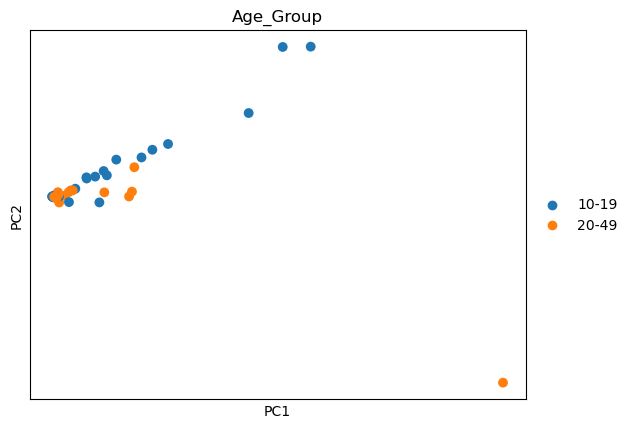

In [29]:
sc.tl.pca(dds)
sc.pl.pca(dds, color = 'Age_Group', size = 200)

In [36]:
dds

AnnData object with n_obs × n_vars = 39 × 37592
    obs: 'dataset_id', 'donor_id', 'sample_id', 'author_cell_type', 'tissue_ontology_term', 'tissue_ontology_term_id', 'tissue_free_text', 'sample_source', 'sample_collection_method', 'tissue_type', 'sampled_site_condition', 'disease_ontology_term', 'disease_ontology_term_id', 'sample_preservation_method', 'suspension_type', 'is_primary_data', 'age_range', 'development_stage_ontology_term_id', 'radial_tissue_term', 'dissociation_protocol', 'cell_enrichment', 'sample_collection_year', 'library_id', 'library_id_repository', 'library_preparation_batch', 'library_sequencing_run', 'sample_collection_site', 'sample_collection_relative_time_point', 'cell_number_loaded', 'cell_viability_percentage', 'institute', 'author_batch_notes', 'organism_ontology_term_id', 'manner_of_death', 'sex_ontology_term', 'sex_ontology_term_id', 'age_at_biopsy', 'consortia', 'study_pi', 'contact_email', 'batch_condition', 'default_embedding', 'sequencing_platform', '

In [42]:
pb.obs['disease_ontology_term'].value_counts(dropna=False)
###functional_gastrointestinal_disorder includes IBS

disease_ontology_term
healthy                                 26
functional_gastrointestinal_disorder    13
Name: count, dtype: int64

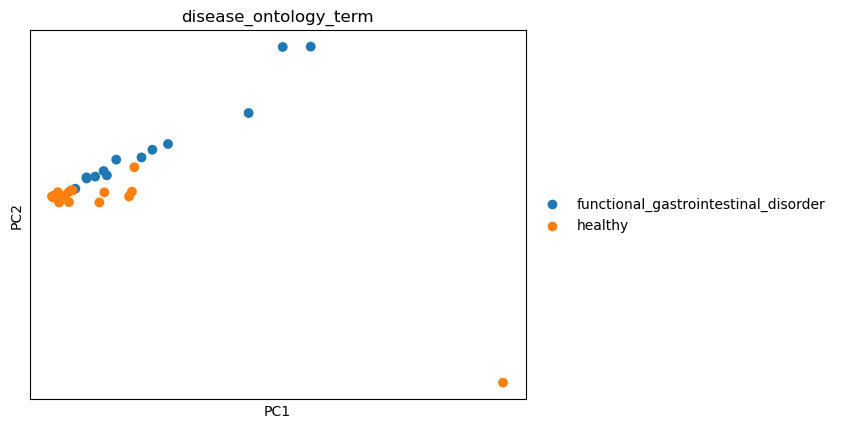

In [43]:
sc.pl.pca(dds, color = 'disease_ontology_term', size = 200)

In [37]:
pb.obs['sample_source'].value_counts(dropna=False)

sample_source
surgical_donor    34
organ_donor        5
Name: count, dtype: int64

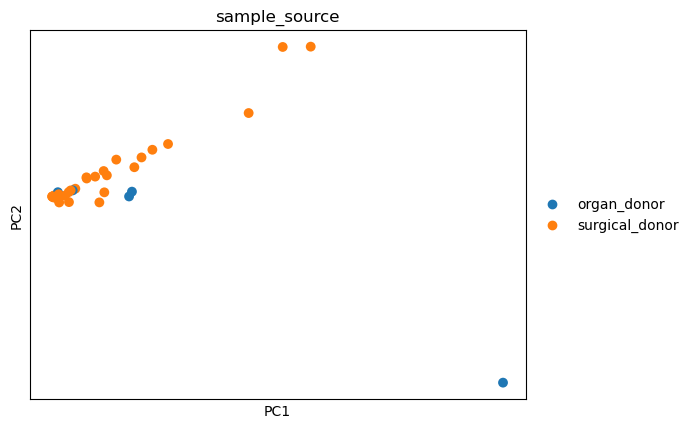

In [38]:
sc.pl.pca(dds, color = 'sample_source', size = 200)

In [30]:
stat_res = DeseqStats(dds, contrast=('Age_Group', "10-19", "20-49"))
#stat_res = DeseqStats(dds, contrast=('Age_Group', "10-19", "20-49"))
stat_res.summary()

Running Wald tests...
... done in 8.01 seconds.



Log2 fold change & Wald test p-value: Age_Group 10-19 vs 20-49
                 baseMean  log2FoldChange     lfcSE      stat    pvalue  \
ENSG00000000003  0.089513       -0.545367  2.289215 -0.238233  0.811700   
ENSG00000000005  0.000000             NaN       NaN       NaN       NaN   
ENSG00000000419  3.553027        0.978040  0.329637  2.967026  0.003007   
ENSG00000000457  0.599419       -1.231262  0.550757 -2.235581  0.025379   
ENSG00000000460  0.257964        0.155052  0.881074  0.175981  0.860309   
...                   ...             ...       ...       ...       ...   
ENSG00000288380  0.083204        0.157945  3.015855  0.052372  0.958233   
ENSG00000288398  0.000000             NaN       NaN       NaN       NaN   
ENSG00000288436  0.000000             NaN       NaN       NaN       NaN   
ENSG00000288459  0.000000             NaN       NaN       NaN       NaN   
ENSG00000288460  0.000000             NaN       NaN       NaN       NaN   

                     padj  
ENSG0000

In [31]:
de = stat_res.results_df

In [32]:
de

,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj
ENSG00000000003,0.089513,-0.545367,2.289215,-0.238233,0.811700,NaN
ENSG00000000005,0.000000,NaN,NaN,NaN,NaN,NaN
ENSG00000000419,3.553027,0.978040,0.329637,2.967026,0.003007,0.083957
ENSG00000000457,0.599419,-1.231262,0.550757,-2.235581,0.025379,NaN
ENSG00000000460,0.257964,0.155052,0.881074,0.175981,0.860309,NaN
...,...,...,...,...,...,...
ENSG00000288380,0.083204,0.157945,3.015855,0.052372,0.958233,NaN
ENSG00000288398,0.000000,NaN,NaN,NaN,NaN,NaN
ENSG00000288436,0.000000,NaN,NaN,NaN,NaN,NaN
ENSG00000288459,0.000000,NaN,NaN,NaN,NaN,NaN


In [33]:
de_sorted = stat_res.results_df.dropna(subset=["padj"]).sort_values("padj")
de_sorted

,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj
ENSG00000265681,109.610383,-2.332790,0.425857,-5.477871,4.304727e-08,0.000114
ENSG00000107317,52.902362,6.737506,1.232558,5.466278,4.595836e-08,0.000114
ENSG00000177576,6.326535,-1.770685,0.331030,-5.349023,8.843037e-08,0.000146
ENSG00000023445,20.901724,2.303880,0.438211,5.257471,1.460502e-07,0.000180
ENSG00000175482,12.022786,-1.947547,0.391416,-4.975643,6.503134e-07,0.000643
...,...,...,...,...,...,...
ENSG00000167613,10.079488,0.000797,0.271461,0.002936,9.976572e-01,0.998686
ENSG00000146731,10.511164,-0.000109,0.190429,-0.000574,9.995422e-01,0.999744
ENSG00000216490,102.279190,0.000353,0.511451,0.000690,9.994491e-01,0.999744
ENSG00000099624,12.406779,0.001532,1.498224,0.001022,9.991843e-01,0.999744


In [34]:
(stat_res.results_df["padj"] < 0.05).sum()

111

In [35]:
(stat_res.results_df["padj"] < 0.05)

ENSG00000000003    False
ENSG00000000005    False
ENSG00000000419    False
ENSG00000000457    False
ENSG00000000460    False
                   ...  
ENSG00000288380    False
ENSG00000288398    False
ENSG00000288436    False
ENSG00000288459    False
ENSG00000288460    False
Name: padj, Length: 37592, dtype: bool